In [8]:
#Importing the Libraries
import pandas as pd
import numpy as np

import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve,precision_score,recall_score,f1_score
)

In [9]:
import os

working_dir = "//wsl.localhost/Ubuntu/home/aaslam123/SummerSchool2026/Module2/AI_project+Report"

os.chdir(working_dir)

print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
\\wsl.localhost\Ubuntu\home\aaslam123\SummerSchool2026\Module2\AI_project+Report


In [11]:
# Load the Datasets

expression_data = pd.read_excel("original_datasets/rna_seq.xlsx")
metadata = pd.read_excel("original_datasets/meta_data.xlsx")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [10]:
print("Expression Matrix")
display(expression_data.head())

Expression Matrix


,Hugo_Symbol,GSM723693,GSM723635,GSM723667,GSM723487,GSM723491,GSM723541,GSM723674,GSM723677,GSM723637,...,GSM723469,GSM723582,GSM723614,GSM723525,GSM723715,GSM723643,GSM723638,GSM723661,GSM723645,GSM723660
0,A1CF,7.387951,7.903160,8.287086,7.051118,7.218319,8.956725,8.045556,8.499669,8.933120,...,8.151577,7.720913,7.738400,7.584984,8.206183,10.163705,9.766135,8.793675,10.896537,7.378069
1,A2M,11.290425,12.168064,12.186582,11.641083,12.261738,11.141571,10.851997,11.603432,11.414677,...,11.249802,11.662979,10.148282,11.335589,11.864852,11.294121,10.577802,10.779547,11.661263,11.568196
2,A4GALT,7.034710,6.713379,6.457136,6.850155,6.483643,6.548152,7.125491,6.577471,6.435551,...,6.386849,7.011791,7.408645,6.300568,6.654325,6.908152,6.615829,6.729571,6.529521,7.042567
3,A4GNT,6.793177,7.016850,6.863772,6.707496,7.251162,6.931640,7.281775,6.824343,6.671469,...,7.184503,7.936410,7.177094,6.874789,6.814188,6.942515,7.095195,6.819416,6.383801,8.035214
4,AAAS,8.495762,8.634507,8.485111,8.807402,8.549352,8.812611,8.649419,8.579454,8.683919,...,8.451579,8.808296,8.739714,8.641013,8.415698,8.566938,8.171919,8.602080,8.703318,8.788436


In [79]:
print("Metadata")
display(metadata.head())

Metadata


,SAMPLE_ID,Phenotype
0,GSM723464,Normal
1,GSM723466,Normal
2,GSM723468,Normal
3,GSM723470,Normal
4,GSM723472,Normal


In [80]:
# Dimensions of both datasets

print("Expression Matrix Shape:", expression_data.shape)
print("Metadata Shape:", metadata.shape)

Expression Matrix Shape: (11903, 268)
Metadata Shape: (267, 2)


In [81]:
#Column names

print("Expression Matrix Columns")
print(expression_data.columns.tolist())

print("\nMetadata Columns")
print(metadata.columns.tolist())

Expression Matrix Columns
['Hugo_Symbol', 'GSM723693', 'GSM723635', 'GSM723667', 'GSM723487', 'GSM723491', 'GSM723541', 'GSM723674', 'GSM723677', 'GSM723637', 'GSM723523', 'GSM723553', 'GSM723516', 'GSM723608', 'GSM723486', 'GSM723722', 'GSM723673', 'GSM723654', 'GSM723519', 'GSM723664', 'GSM723590', 'GSM723718', 'GSM723610', 'GSM723587', 'GSM723477', 'GSM723599', 'GSM723532', 'GSM723464', 'GSM723560', 'GSM723537', 'GSM723534', 'GSM723595', 'GSM723476', 'GSM723510', 'GSM723504', 'GSM723594', 'GSM723474', 'GSM723468', 'GSM723611', 'GSM723652', 'GSM723467', 'GSM723731', 'GSM723698', 'GSM723658', 'GSM723571', 'GSM723568', 'GSM723710', 'GSM723640', 'GSM723472', 'GSM723681', 'GSM723547', 'GSM723540', 'GSM723548', 'GSM723688', 'GSM723670', 'GSM723682', 'GSM723690', 'GSM723612', 'GSM723559', 'GSM723586', 'GSM723657', 'GSM723556', 'GSM723622', 'GSM723697', 'GSM723465', 'GSM723642', 'GSM723518', 'GSM723728', 'GSM723528', 'GSM723648', 'GSM723593', 'GSM723623', 'GSM723694', 'GSM723676', 'GSM72363

In [82]:
#Dataset information
print("Expression Matrix Information")
expression_data.info()

print("\nMetadata Information")
metadata.info()

Expression Matrix Information
<class 'pandas.DataFrame'>
RangeIndex: 11903 entries, 0 to 11902
Columns: 268 entries, Hugo_Symbol to GSM723660
dtypes: float64(267), str(1)
memory usage: 24.3 MB

Metadata Information
<class 'pandas.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   SAMPLE_ID  267 non-null    str  
 1   Phenotype  267 non-null    str  
dtypes: str(2)
memory usage: 4.3 KB


In [83]:
expression_data.describe()

,GSM723693,GSM723635,GSM723667,GSM723487,GSM723491,GSM723541,GSM723674,GSM723677,GSM723637,GSM723523,...,GSM723469,GSM723582,GSM723614,GSM723525,GSM723715,GSM723643,GSM723638,GSM723661,GSM723645,GSM723660
count,11903.000000,11903.000000,11903.000000,11903.000000,11903.000000,11903.000000,11903.000000,11903.000000,11903.000000,11903.000000,...,11903.000000,11903.000000,11903.000000,11903.000000,11903.000000,11903.000000,11903.000000,11903.000000,11903.000000,11903.000000
mean,7.534413,7.511813,7.516634,7.489828,7.507423,7.503056,7.478961,7.511825,7.492614,7.495319,...,7.495562,7.479193,7.474840,7.501263,7.500659,7.489382,7.513164,7.490400,7.504464,7.505211
std,1.714815,1.652444,1.680670,1.732791,1.676783,1.737201,1.551998,1.701399,1.730910,1.655798,...,1.706543,1.621756,1.571598,1.718360,1.702147,1.634974,1.661586,1.706244,1.738369,1.671740
min,3.817147,3.819490,3.789404,3.700737,3.785616,3.745993,3.782788,3.788177,3.778473,3.793773,...,3.805204,3.791225,3.825704,3.769680,3.741788,3.808374,3.816581,3.753696,3.730329,3.745941
25%,6.283132,6.332937,6.320537,6.239928,6.313072,6.217263,6.439900,6.283291,6.236074,6.310825,...,6.286879,6.364690,6.428120,6.257871,6.277240,6.328630,6.360430,6.228790,6.221234,6.322241
50%,7.533401,7.546022,7.531560,7.449951,7.532880,7.504908,7.513549,7.528371,7.480686,7.498611,...,7.470648,7.492208,7.495916,7.489224,7.500609,7.489726,7.508067,7.486905,7.490440,7.523701
75%,8.674679,8.592304,8.628311,8.636011,8.623333,8.687748,8.470675,8.663529,8.638616,8.580089,...,8.604468,8.497744,8.470893,8.648203,8.631707,8.598506,8.572921,8.643559,8.680907,8.609989
max,14.214197,14.477365,14.404038,14.472185,14.256193,14.083749,14.677887,14.303610,13.997584,14.374036,...,14.206925,14.621869,14.556175,14.414524,14.079781,13.911787,14.304501,14.287065,14.460353,14.378425


In [ ]:
# download the expression data.describe() to a CSV file inclusing first column as index and without index column
expression_data.describe().to_csv("datasets/expression_data_summary.csv", index=True)

In [85]:
#class distribution in the metadata
metadata["Phenotype"].value_counts()

Phenotype
GC        134
Normal    133
Name: count, dtype: int64

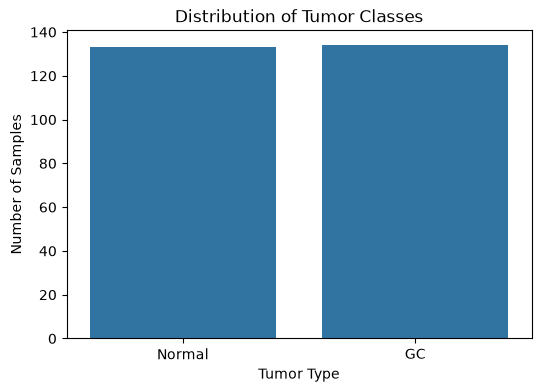

In [86]:
# Visualize the Distribution of Tumor Classes

plt.figure(figsize=(6,4))
sns.countplot(
    data=metadata,
    x="Phenotype"
)

plt.title("Distribution of Tumor Classes")
plt.xlabel("Tumor Type")
plt.ylabel("Number of Samples")
plt.show()

In [87]:
# Explore the Expression Data (whether it needs log transformation or not) 
print("Minimum Expression Value:",
      expression_data.iloc[:,1:].min().min())

print("Maximum Expression Value:",
      expression_data.iloc[:,1:].max().max())

Minimum Expression Value: 3.65143428579676
Maximum Expression Value: 14.8524297022047


In [88]:
# Handling Missing Values

print("Missing Value Assessment")
before_rows = expression_data.shape[0]
missing_values = expression_data.isnull().sum().sum()
print(f"Total Missing Values: {missing_values}")

# Remove missing values (if any)
expression_data = expression_data.dropna()
after_rows = expression_data.shape[0]

print(f"\nRows Before : {before_rows}")
print(f"Rows After  : {after_rows}")
print(f"Rows Removed: {before_rows-after_rows}")

Missing Value Assessment
Total Missing Values: 0

Rows Before : 11903
Rows After  : 11903
Rows Removed: 0


In [89]:
# Removing Duplicate Rows
print("Duplicate Row Assessment")
before_rows = expression_data.shape[0]
duplicates = expression_data.duplicated().sum()
print(f"Duplicate Rows Found: {duplicates}")

expression_data = expression_data.drop_duplicates()
after_rows = expression_data.shape[0]

print(f"\nRows Before : {before_rows}")
print(f"Rows After  : {after_rows}")
print(f"Rows Removed: {before_rows-after_rows}")

Duplicate Row Assessment
Duplicate Rows Found: 0

Rows Before : 11903
Rows After  : 11903
Rows Removed: 0



We checked: **0 of the ~11,900 genes have any zero values**, and the expression range (~3.8–14.5) already looks log-scaled. Applying `log2(x+1)` again would distort the data (double-log), and a zero-fraction filter has nothing to remove. So we go straight to variance filtering, which is unaffected by this.

In [90]:
print("Dataset Shape:", expression_data.shape)

Dataset Shape: (11903, 268)


In [91]:
# Calculate Gene Variance
gene_variance = expression_data.iloc[:, 1:].var(axis=1)

print("Gene Variance Summary\n", gene_variance.describe())

Gene Variance Summary
 count    11903.000000
mean         0.215076
std          0.428999
min          0.003370
25%          0.057077
50%          0.103151
75%          0.211550
max         12.002374
dtype: float64


In [92]:
# Evaluating Different Variance Thresholds
thresholds = [0.1, 0.25, 0.5, 1.0]

print("=" * 75)
print(f"{'Threshold':<15}{'Genes Removed':<20}{'Genes Remaining'}")
print("=" * 75)

for threshold in thresholds:
    filtered = expression_data[gene_variance >= threshold]
    removed = expression_data.shape[0] - filtered.shape[0]
    print(f"{threshold:<15}{removed:<20}{filtered.shape[0]}")

Threshold      Genes Removed       Genes Remaining
0.1            5822                6081
0.25           9417                2486
0.5            10845               1058
1.0            11531               372


In [ ]:
# Remove Low-Variance Genes

variance_threshold = 0.25

gene_variance = expression_data.iloc[:, 1:].var(axis=1)

expression_variance_filtered = expression_data[gene_variance >= variance_threshold]

genes_before = expression_data.shape[0]
genes_after = expression_variance_filtered.shape[0]


print("Low Variance Filtering Summary")
print(f"Variance Threshold Used     : {variance_threshold}")
print(f"Genes Before Filtering      : {genes_before}")
print(f"Genes After Filtering       : {genes_after}")
print(f"Genes Removed               : {genes_before - genes_after}")
print(f"Percentage Retained         : {(genes_after/genes_before)*100:.2f}%")

expression_variance_filtered.to_excel("datasets/01_Variance_Filtered_Data.xlsx", index=False)

Low Variance Filtering Summary
Variance Threshold Used     : 0.25
Genes Before Filtering      : 11903
Genes After Filtering       : 2486
Genes Removed               : 9417
Percentage Retained         : 20.89%


In [94]:
# Final Preprocessed Dataset Dimensions
print("Final Preprocessed Dataset")

print(f"Number of Genes (Rows)     : {expression_variance_filtered.shape[0]}")
print(f"Number of Samples (Columns): {expression_variance_filtered.shape[1]-1}")
print(f"Dataset Shape              : {expression_variance_filtered.shape}")

Final Preprocessed Dataset
Number of Genes (Rows)     : 2486
Number of Samples (Columns): 267
Dataset Shape              : (2486, 268)


In [95]:
# Prepare Data for Correlation Analysis

correlation_data = expression_variance_filtered.set_index(
    expression_variance_filtered.columns[0]
)

print(f"Genes   : {correlation_data.shape[0]}")
print(f"Samples : {correlation_data.shape[1]}")

Genes   : 2486
Samples : 267


In [96]:
# Calculate Gene Correlation Matrix

correlation_matrix = correlation_data.T.corr(method="pearson")
print("Correlation Matrix Shape:", correlation_matrix.shape)

Correlation Matrix Shape: (2486, 2486)


In [97]:
# Inspecting the Correlation Matrix
print("Correlation Matrix Overview")

print(f"Number of Genes              : {correlation_matrix.shape[0]}")
print(f"Number of Correlation Values : {correlation_matrix.size:,}")
print(f"Matrix Shape                 : {correlation_matrix.shape}")

Correlation Matrix Overview
Number of Genes              : 2486
Number of Correlation Values : 6,180,196
Matrix Shape                 : (2486, 2486)


In [98]:
# Display the first 10 rows and columns of the correlation matrix
correlation_matrix.iloc[:10, :10]

Hugo_Symbol,A1CF,A2M,A4GNT,AADAC,AASDHPPT,ABCA1,ABCA5,ABCA8,ABCC3,ABCC5
Hugo_Symbol,,,,,,,,,,
A1CF,1.000000,-0.129940,-0.080950,0.220156,-0.007029,-0.181931,0.172099,-0.157759,0.208446,-0.082051
A2M,-0.129940,1.000000,-0.271092,-0.354890,0.172508,0.603896,-0.494840,0.418418,-0.138871,-0.343537
A4GNT,-0.080950,-0.271092,1.000000,0.537244,-0.236724,-0.260465,0.272902,0.129685,0.276136,0.419308
AADAC,0.220156,-0.354890,0.537244,1.000000,-0.269107,-0.386899,0.445525,0.128011,0.536882,0.591895
AASDHPPT,-0.007029,0.172508,-0.236724,-0.269107,1.000000,0.526359,-0.033505,-0.098805,-0.213445,-0.351388
ABCA1,-0.181931,0.603896,-0.260465,-0.386899,0.526359,1.000000,-0.364882,0.177060,-0.253722,-0.419179
ABCA5,0.172099,-0.494840,0.272902,0.445525,-0.033505,-0.364882,1.000000,0.109546,0.211236,0.465733
ABCA8,-0.157759,0.418418,0.129685,0.128011,-0.098805,0.177060,0.109546,1.000000,-0.202857,0.218029
ABCC3,0.208446,-0.138871,0.276136,0.536882,-0.213445,-0.253722,0.211236,-0.202857,1.000000,0.381421


In [99]:
# Checking Diagonal Values

diagonal_values = np.diag(correlation_matrix)
print("Diagonal Inspection")
print("Unique values on diagonal:",np.unique(diagonal_values))


Diagonal Inspection
Unique values on diagonal: [1.]


In [100]:
# Extract Upper Triangle
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

correlation_values = upper_triangle.stack()

print("Unique Gene Pair Correlations")

print(f"Total Unique Gene Pairs : {len(correlation_values):,}")

Unique Gene Pair Correlations
Total Unique Gene Pairs : 6,180,196


In [101]:
# Correlation Statistics

print("Correlation Summary")

print(correlation_values.describe())

Correlation Summary
count    3.088855e+06
mean     4.532487e-02
std      3.086852e-01
min     -8.466374e-01
25%     -1.747411e-01
50%      3.294297e-02
75%      2.660282e-01
max      9.926041e-01
dtype: float64


In [102]:
# Evaluating Different Correlation Thresholds

thresholds = [0.80, 0.85, 0.90, 0.95]

print("="*90)
print(f"{'Threshold':<12}"
      f"{'Correlated Pairs':<22}"
      f"{'Genes Removed':<20}"
      f"{'Genes Remaining'}")
print("="*90)

total_genes = correlation_matrix.shape[0]
removed_counts = []

for threshold in thresholds:

    # Select upper triangle only
    upper = correlation_matrix.where(
        np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
    )

    # Find genes to remove
    to_drop = [
        column for column in upper.columns
        if any(upper[column] > threshold)
    ]

    genes_removed = len(to_drop)
    genes_remaining = total_genes - genes_removed

    # Count correlated gene pairs
    correlated_pairs = (
        upper.stack() > threshold
    ).sum()

    print(f"{threshold:<12}"
          f"{correlated_pairs:<22}"
          f"{genes_removed:<20}"
          f"{genes_remaining}")
    removed_counts.append(genes_removed)

Threshold   Correlated Pairs      Genes Removed       Genes Remaining
0.8         8913                  791                 1695
0.85        2819                  414                 2072
0.9         512                   160                 2326
0.95        47                    25                  2461


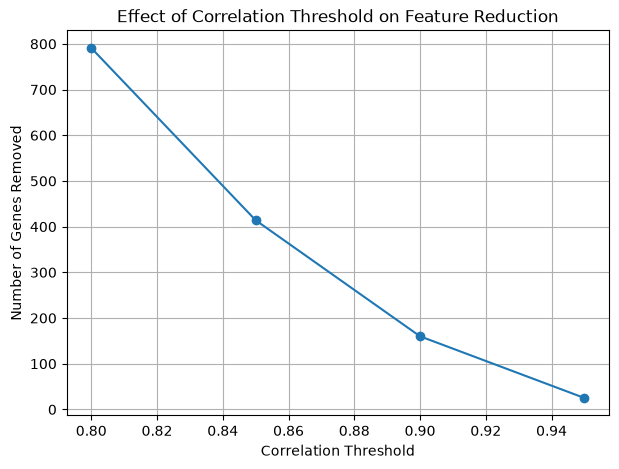

In [103]:
# Plot the number of genes removed against the correlation thresholds
plt.figure(figsize=(7,5))

plt.plot(thresholds, removed_counts, marker='o')

plt.xlabel("Correlation Threshold")
plt.ylabel("Number of Genes Removed")
plt.title("Effect of Correlation Threshold on Feature Reduction")

plt.grid(True)

plt.show()

In [ ]:
# Remove Highly Correlated Genes
correlation_threshold = 0.85

genes_to_remove = [
    c for c in upper_triangle.columns if any(upper_triangle[c] > correlation_threshold)
]

#remove redundant genes from the correlation data
expression_correlation_filtered = correlation_data.drop(index=genes_to_remove)

print("="*60)
print("Correlation Filtering Summary")
print("="*60)
print(f"Threshold Used            : {correlation_threshold}")
print(f"Genes Before Filtering    : {correlation_data.shape[0]}")
print(f"Genes Removed             : {len(genes_to_remove)}")
print(f"Genes Remaining           : {expression_correlation_filtered.shape[0]}")

expression_correlation_filtered = expression_correlation_filtered.reset_index()
expression_correlation_filtered.to_excel("datasets/02_Correlation_Filtered_Data.xlsx", index=False)

Correlation Filtering Summary
Threshold Used            : 0.85
Genes Before Filtering    : 2486
Genes Removed             : 414
Genes Remaining           : 2072


C:\Users\PMLS\AppData\Local\Temp\ipykernel_12984\2986351857.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  expression_correlation_filtered = expression_correlation_filtered.reset_index()


In [105]:
#Supervised Feature Selection using ANOVA F-test

# Merge Expression Data with Metadata

expression_indexed = expression_correlation_filtered.set_index(expression_correlation_filtered.columns[0])
expression_ml = expression_indexed.T

merged_data = expression_ml.merge(
    metadata, left_index=True, right_on="SAMPLE_ID", how="inner"
)

print("Merged Dataset Shape:", merged_data.shape)
print(merged_data["Phenotype"].value_counts())
print("Missing Labels:", merged_data["Phenotype"].isna().sum())

Merged Dataset Shape: (267, 2074)
Phenotype
GC        134
Normal    133
Name: count, dtype: int64
Missing Labels: 0


In [106]:
# Label Encoding: Normal = 0, GC (Gastric Cancer) = 1
label_map = {"Normal": 0, "GC": 1}
merged_data["Class"] = merged_data["Phenotype"].map(label_map)

print(merged_data["Class"].value_counts())

Class
1    134
0    133
Name: count, dtype: int64


In [107]:
# Feature Matrix and Target Vector

X = merged_data.drop(columns=["SAMPLE_ID", "Phenotype", "Class"])
y = merged_data["Class"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape         :", y.shape)

Feature Matrix Shape : (267, 2072)
Target Shape         : (267,)


In [108]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")
print("\nTraining Set Class Distribution")
print(y_train.value_counts())
print("\nTesting Set Class Distribution")
print(y_test.value_counts())

Training Samples : 213
Testing Samples  : 54

Training Set Class Distribution
Class
1    107
0    106
Name: count, dtype: int64

Testing Set Class Distribution
Class
0    27
1    27
Name: count, dtype: int64


In [109]:
from sklearn.feature_selection import f_classif

In [110]:
# ANOVA F-scores

F_scores, p_values = f_classif(X_train, y_train)

anova_results = pd.DataFrame({
    "Gene": X_train.columns, "F_score": F_scores, "P_value": p_values
}).sort_values(by="F_score", ascending=False).reset_index(drop=True)

display(anova_results.head(20))

,Gene,F_score,P_value
0,ALDH6A1,443.758841,8.669651e-54
1,CTSB,384.063051,2.131354e-49
2,MT1E,358.918454,2.051442e-47
3,BGN,358.493054,2.220065e-47
4,AKR7A3,342.546062,4.480550e-46
5,SIDT2,319.311957,4.186388e-44
6,ADTRP,319.083591,4.381624e-44
7,UBL3,317.849999,5.606808e-44
8,FAM189A2,295.700759,5.191595e-42
9,ADGRG2,294.178011,7.139399e-42


In [111]:
# Number of Significant Genes at Different Thresholds

for threshold in [0.05, 0.01, 0.001, 0.0001]:
    count = (anova_results["P_value"] < threshold).sum()
    print(f"P-value < {threshold:<8} : {count} genes")

P-value < 0.05     : 1657 genes
P-value < 0.01     : 1539 genes
P-value < 0.001    : 1384 genes
P-value < 0.0001   : 1272 genes


In [ ]:
significant_genes = anova_results[anova_results["P_value"] <= 0.05].copy()
print(f"Total Significant Genes : {significant_genes.shape[0]}")
significant_genes.to_excel("datasets/ANOVA_Significant_Genes.xlsx", index=False)

Total Significant Genes : 1657


In [113]:
# describe the significant_genes dataframe
significant_genes.describe()

,F_score,P_value
count,1657.000000,1.657000e+03
mean,64.751451,2.181756e-03
std,62.017283,7.251841e-03
min,3.894869,8.669651e-54
25%,17.713160,1.395120e-18
50%,44.364461,2.325442e-10
75%,93.762649,3.799854e-05
max,443.758841,4.973896e-02


In [114]:
significant_genes.head(20)

,Gene,F_score,P_value
0,ALDH6A1,443.758841,8.669651e-54
1,CTSB,384.063051,2.131354e-49
2,MT1E,358.918454,2.051442e-47
3,BGN,358.493054,2.220065e-47
4,AKR7A3,342.546062,4.480550e-46
5,SIDT2,319.311957,4.186388e-44
6,ADTRP,319.083591,4.381624e-44
7,UBL3,317.849999,5.606808e-44
8,FAM189A2,295.700759,5.191595e-42
9,ADGRG2,294.178011,7.139399e-42


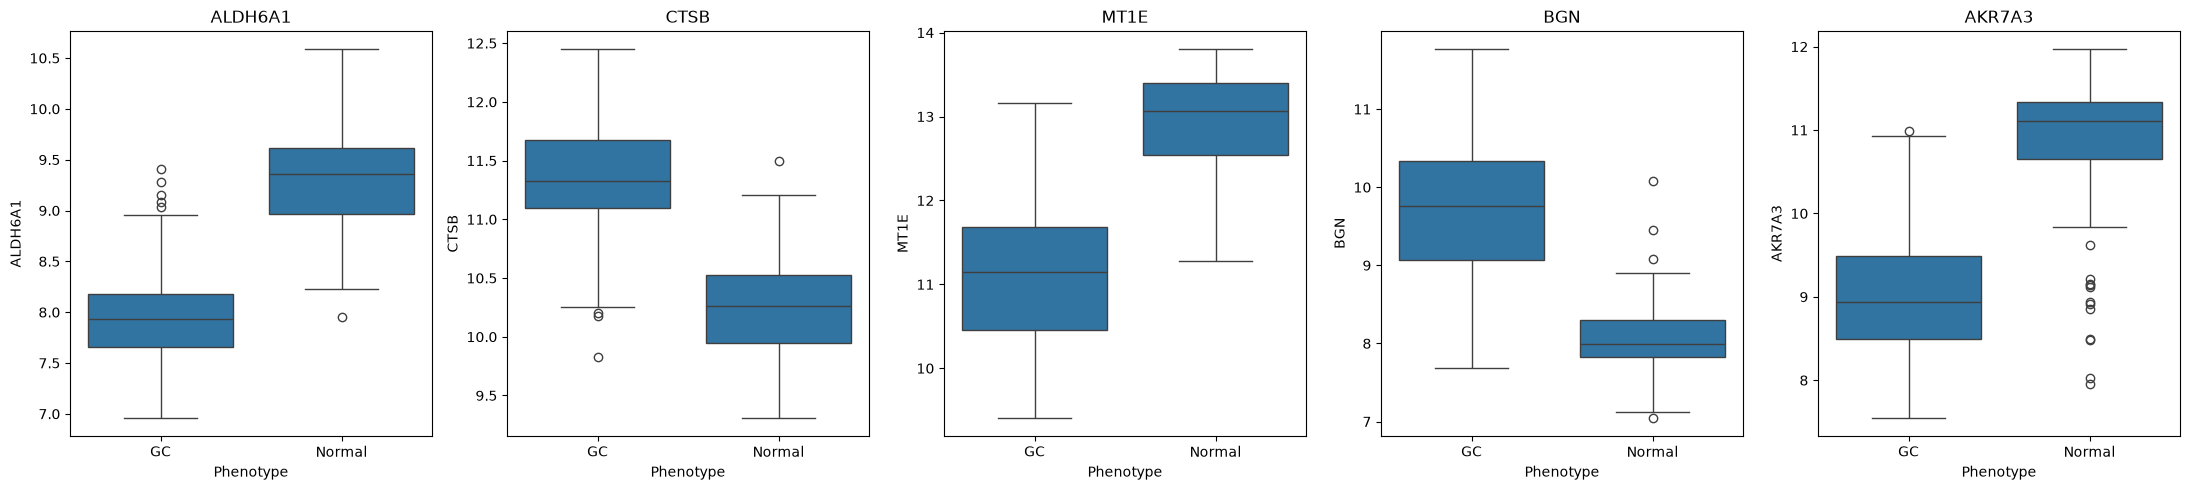

In [115]:
# Boxplots of top 5 most discriminative genes
top5 = significant_genes.head(5)["Gene"]

fig, axes = plt.subplots(1, 5, figsize=(22,5))
for i, gene in enumerate(top5):
    sns.boxplot(x=merged_data["Phenotype"], y=merged_data[gene], ax=axes[i])
    axes[i].set_title(gene)
plt.tight_layout()
plt.show()

In [ ]:
# Final Feature Selection

k = 500
selected_genes = significant_genes.head(k)["Gene"]

X_train_selected = X_train[selected_genes]
X_test_selected = X_test[selected_genes]

print(f"Training Set : {X_train_selected.shape}")
print(f"Testing Set  : {X_test_selected.shape}")

X_train_selected.to_excel(f"datasets/X_train_Top_{k}_Genes.xlsx")
X_test_selected.to_excel(f"datasets/X_test_Top_{k}_Genes.xlsx")

Training Set : (213, 500)
Testing Set  : (54, 500)


In [117]:
# ==========================================================
# Standardize Features (required for KNN)
# ==========================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

X_train_scaled_df = pd.DataFrame(X_train_scaled, index=X_train_selected.index, columns=X_train_selected.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, index=X_test_selected.index, columns=X_test_selected.columns)

print("Training Shape :", X_train_scaled_df.shape)
print("Testing Shape  :", X_test_scaled_df.shape)

Training Shape : (213, 500)
Testing Shape  : (54, 500)


In [118]:
print("Training Shape :", X_train_scaled_df.head())
print("Testing Shape  :", X_test_scaled_df.head())

Training Shape :      ALDH6A1      CTSB      MT1E       BGN    AKR7A3     SIDT2     ADTRP  \
81  1.113646 -1.295592  1.365908 -0.919024  1.185478  0.727380  1.263630   
40  0.285626 -0.130549 -0.491641 -1.217433  1.017842  0.373183  1.719208   
64  1.964775 -1.846274  1.151420 -0.563993  1.438939  1.034958  0.556342   
30  0.927396 -0.919424  0.685850 -0.779638  1.029433  0.567284  0.792662   
82  1.812784 -2.170221  1.602001 -0.249940  1.758142  1.637515  1.827494   

        UBL3  FAM189A2    ADGRG2  ...    ITGBL1      MCM4    PAPSS1    TOM1L1  \
81  0.978874  1.471989  1.492945  ... -0.809888 -1.203733  0.751652  0.289648   
40  0.340448  0.151398  0.273600  ... -0.844118  0.249796  0.796117 -0.030674   
64  1.464910  1.406363  1.636207  ... -0.708460 -0.332659  1.619396  0.997093   
30  1.140335  0.757404  0.620649  ... -0.783624  0.735437  1.918075  1.164695   
82  1.266627  0.882577  1.321512  ... -0.313093 -1.332958  1.377127 -0.026891   

        GPX3    HOXA10      MBD2     MS

In [119]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled_df, y_train)

y_pred_knn = knn_model.predict(X_test_scaled_df)
y_prob_knn = knn_model.predict_proba(X_test_scaled_df)[:, 1]

accuracy = accuracy_score(y_test, y_pred_knn)
precision = precision_score(y_test, y_pred_knn, average='weighted')
recall = recall_score(y_test, y_pred_knn, average='weighted')
f1 = f1_score(y_test, y_pred_knn, average='weighted')
auc_score = roc_auc_score(y_test, y_prob_knn)

print(f"Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUC      : {auc_score:.4f}")

Accuracy : 0.9444 (94.44%)
Precision: 0.9451
Recall   : 0.9444
F1 Score : 0.9444
AUC      : 0.9602


In [ ]:
# Final Performance Summary,saving the file


summary = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "AUC"
    ],

    "Value":[
        accuracy,
        precision,
        recall,
        f1,
        auc_score
    ]

})

summary["Value"] = summary["Value"].round(4)


summary.to_excel("datasets/KNN_Performance.xlsx", index=False)

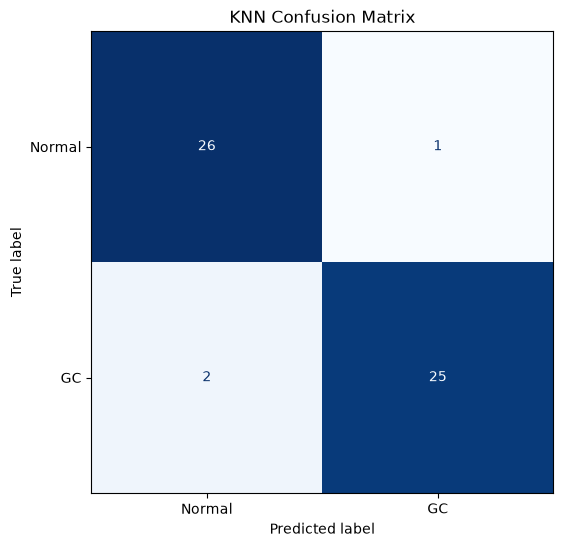

In [121]:
cm = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "GC"])
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(cmap="Blues", ax=ax, colorbar=False)
plt.title("KNN Confusion Matrix")
plt.grid(False)
plt.show()


In [122]:
comparison_knn = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_knn
})

comparison_knn.head(10)

,Actual,Predicted
26,0,0
208,1,1
37,0,0
119,0,0
72,0,0
19,0,0
117,0,0
84,0,0
6,0,0
199,1,0


In [ ]:
comparison_knn.to_excel(
    "datasets/KNN_Predictions.xlsx",
    index=False
)


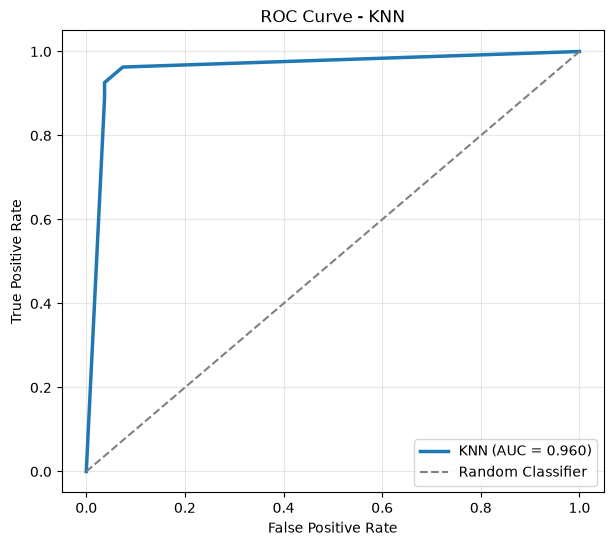

In [124]:
fpr, tpr, _ = roc_curve(y_test, y_prob_knn)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, linewidth=2.5, label=f"KNN (AUC = {auc_score:.3f})")
plt.plot([0,1],[0,1], linestyle="--", color="gray", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [125]:
# Decision Tree Model
dt_model = DecisionTreeClassifier(criterion="gini", max_depth=5, random_state=42)
dt_model.fit(X_train_selected, y_train)

y_pred_dt = dt_model.predict(X_test_selected)

# Predict Test Samples
print(f"Total Test Samples : {len(y_test)}")

y_prob_dt = dt_model.predict_proba(X_test_selected)[:, 1]

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt, average="weighted")
dt_recall = recall_score(y_test, y_pred_dt, average="weighted")
dt_f1 = f1_score(y_test, y_pred_dt, average="weighted")
dt_auc = roc_auc_score(y_test, y_prob_dt)

print(f"Accuracy : {dt_accuracy:.4f} ({dt_accuracy*100:.2f}%)")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1 Score : {dt_f1:.4f}")
print(f"AUC      : {dt_auc:.4f}")

Total Test Samples : 54
Accuracy : 0.8889 (88.89%)
Precision: 0.8910
Recall   : 0.8889
F1 Score : 0.8887
AUC      : 0.8889


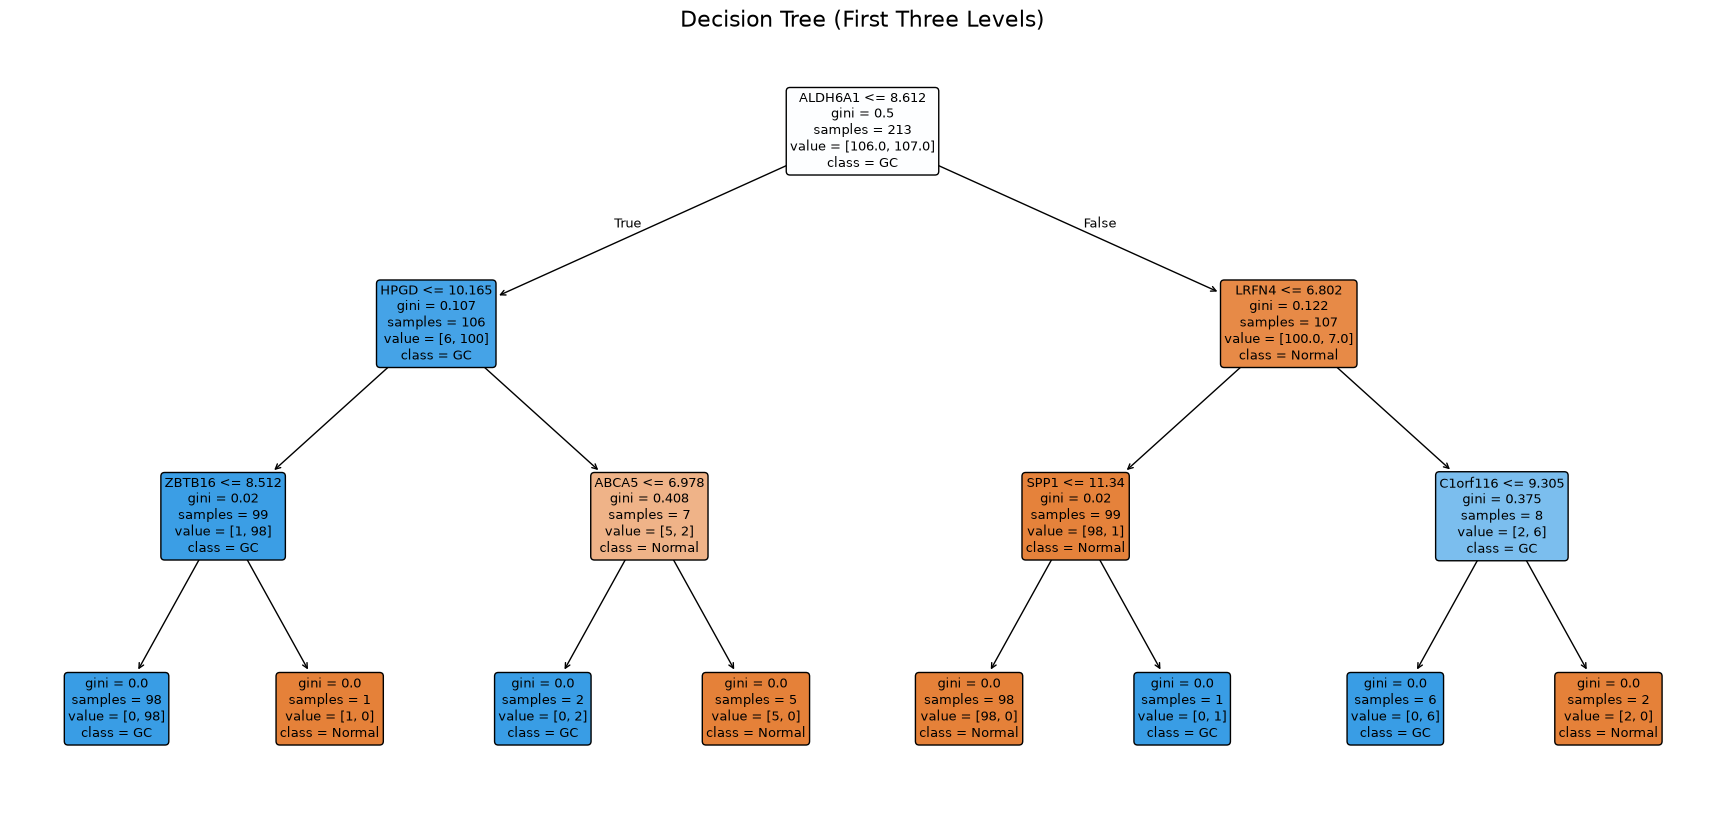

In [126]:
from sklearn.tree import plot_tree

plt.figure(figsize=(22,10))
plot_tree(dt_model, feature_names=X_train_selected.columns, class_names=["Normal","GC"],
          filled=True, rounded=True, fontsize=9, max_depth=3)
plt.title("Decision Tree (First Three Levels)", fontsize=16)
plt.show()

In [127]:
#Classification Report
print("Classification Report")

print(classification_report(y_test, y_pred_dt))

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.85      0.88        27
           1       0.86      0.93      0.89        27

    accuracy                           0.89        54
   macro avg       0.89      0.89      0.89        54
weighted avg       0.89      0.89      0.89        54



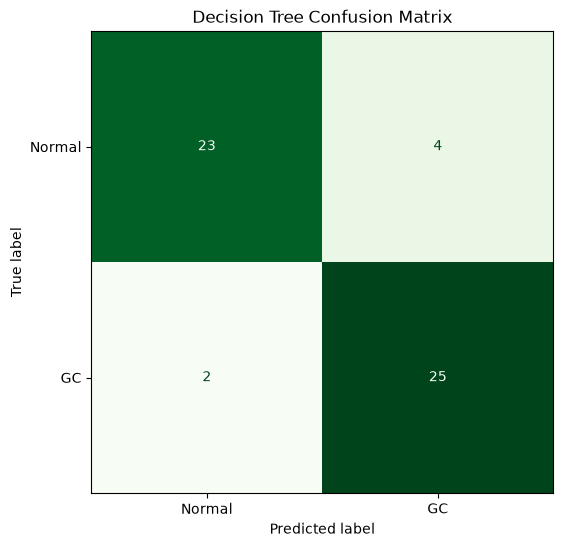

In [128]:
# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["Normal", "GC"]
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    cmap="Greens",
    ax=ax,
    colorbar=False
)

plt.title("Decision Tree Confusion Matrix")

plt.grid(False)

plt.show()

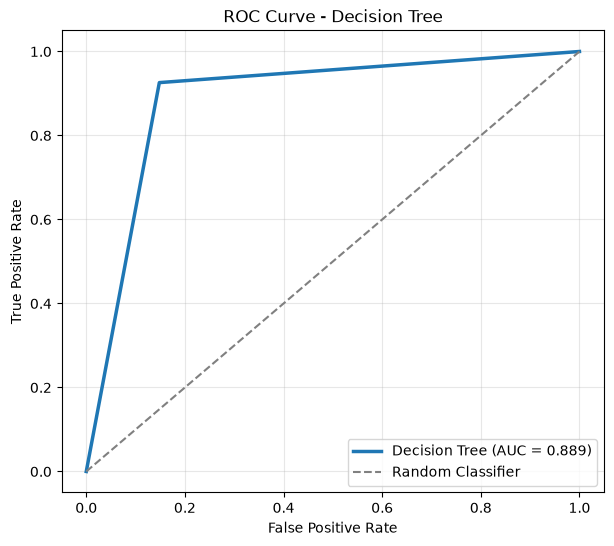

In [129]:
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

plt.figure(figsize=(7,6))
plt.plot(fpr_dt, tpr_dt, linewidth=2.5, label=f"Decision Tree (AUC = {dt_auc:.3f})")
plt.plot([0,1],[0,1], linestyle="--", color="gray", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [130]:
# Actual vs Predicted Labels

dt_predictions = pd.DataFrame({

    "Actual": y_test,
    "Predicted": y_pred_dt

})

print("="*70)
print("Decision Tree Predictions")
print("="*70)

display(dt_predictions.head(20))

Decision Tree Predictions


,Actual,Predicted
26,0,0
208,1,1
37,0,0
119,0,0
72,0,1
19,0,0
117,0,0
84,0,0
6,0,0
199,1,1


In [131]:
# Decision Tree Performance Summary

dt_summary = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "AUC"
    ],

    "Value":[
        dt_accuracy,
        dt_precision,
        dt_recall,
        dt_f1,
        dt_auc
    ]

})

dt_summary["Value"] = dt_summary["Value"].round(4)

dt_summary

,Metric,Value
0,Accuracy,0.8889
1,Precision,0.8910
2,Recall,0.8889
3,F1-score,0.8887
4,AUC,0.8889


In [ ]:
# Save Decision Tree Results

dt_summary.to_excel(
    "datasets/DecisionTree_Performance.xlsx",
    index=False
)

dt_predictions.to_excel(
    "datasets/DecisionTree_Predictions.xlsx",
    index=False
)

print("="*70)
print("Decision Tree Analysis Completed Successfully")
print("="*70)

print("Files Generated")
print("------------------------------")
print("1. DecisionTree_Performance.xlsx")
print("2. DecisionTree_Predictions.xlsx")

Decision Tree Analysis Completed Successfully
Files Generated
------------------------------
1. DecisionTree_Performance.xlsx
2. DecisionTree_Predictions.xlsx


In [133]:
rf_model = RandomForestClassifier(n_estimators=200, criterion="gini", max_depth=None, random_state=42, n_jobs=-1)
rf_model.fit(X_train_selected, y_train)

y_pred_rf = rf_model.predict(X_test_selected)
y_prob_rf = rf_model.predict_proba(X_test_selected)[:, 1]

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average="weighted")
rf_recall = recall_score(y_test, y_pred_rf, average="weighted")
rf_f1 = f1_score(y_test, y_pred_rf, average="weighted")
rf_auc = roc_auc_score(y_test, y_prob_rf)

print(f"Accuracy : {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"AUC      : {rf_auc:.4f}")

Accuracy : 0.9630 (96.30%)
Precision: 0.9630
Recall   : 0.9630
F1 Score : 0.9630
AUC      : 0.9595


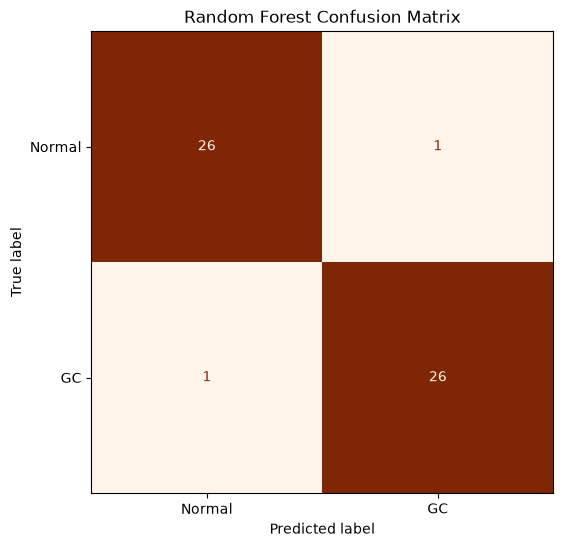

In [134]:
# Confusion Matrix

cm_rf = confusion_matrix(y_test,y_pred_rf)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm_rf,
    display_labels=["Normal", "GC"]

)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    cmap="Oranges",
    ax=ax,
    colorbar=False
)

plt.title("Random Forest Confusion Matrix")

plt.grid(False)

plt.show()

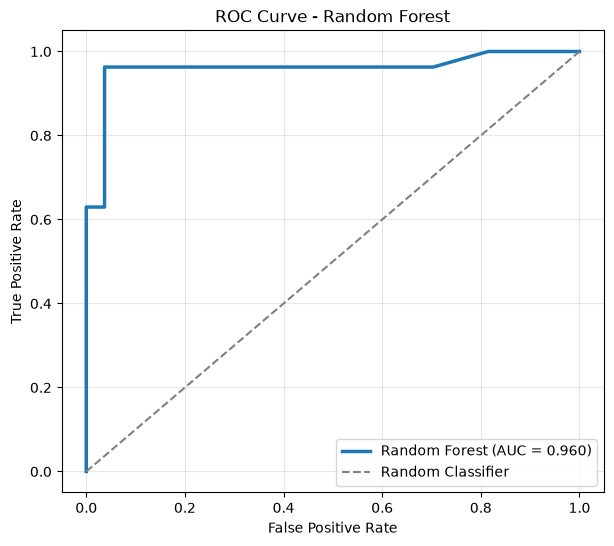

In [135]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(7,6))
plt.plot(fpr_rf, tpr_rf, linewidth=2.5, label=f"Random Forest (AUC = {rf_auc:.3f})")
plt.plot([0,1],[0,1], linestyle="--", color="gray", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [136]:
rf_predictions = pd.DataFrame({

    "Actual":y_test,
    "Predicted":y_pred_rf

})

rf_predictions.head(20)

,Actual,Predicted
26,0,0
208,1,1
37,0,0
119,0,0
72,0,0
19,0,0
117,0,0
84,0,0
6,0,0
199,1,1


In [137]:
rf_summary = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "AUC"
    ],

    "Value":[
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_auc
    ]

})

rf_summary["Value"] = rf_summary["Value"].round(4)

rf_summary

,Metric,Value
0,Accuracy,0.9630
1,Precision,0.9630
2,Recall,0.9630
3,F1-score,0.9630
4,AUC,0.9595


In [ ]:
rf_summary.to_excel(
    "datasets/RandomForest_Performance.xlsx",
    index=False
)

rf_predictions.to_excel(
    "datasets/RandomForest_Predictions.xlsx",
    index=False
)

In [ ]:
#COMPARISON OF ALL MODELS

comparison = pd.DataFrame({
    "Model": ["K-Nearest Neighbors", "Decision Tree", "Random Forest"],
    "Accuracy": [accuracy, dt_accuracy, rf_accuracy],
    "Precision": [precision, dt_precision, rf_precision],
    "Recall": [recall, dt_recall, rf_recall],
    "F1-score": [f1, dt_f1, rf_f1],
    "AUC": [auc_score, dt_auc, rf_auc],
}).round(4)

display(comparison)
comparison.to_excel("datasets/Model_Comparison.xlsx", index=False)

,Model,Accuracy,Precision,Recall,F1-score,AUC
0,K-Nearest Neighbors,0.9444,0.9451,0.9444,0.9444,0.9602
1,Decision Tree,0.8889,0.8910,0.8889,0.8887,0.8889
2,Random Forest,0.9630,0.9630,0.9630,0.9630,0.9595


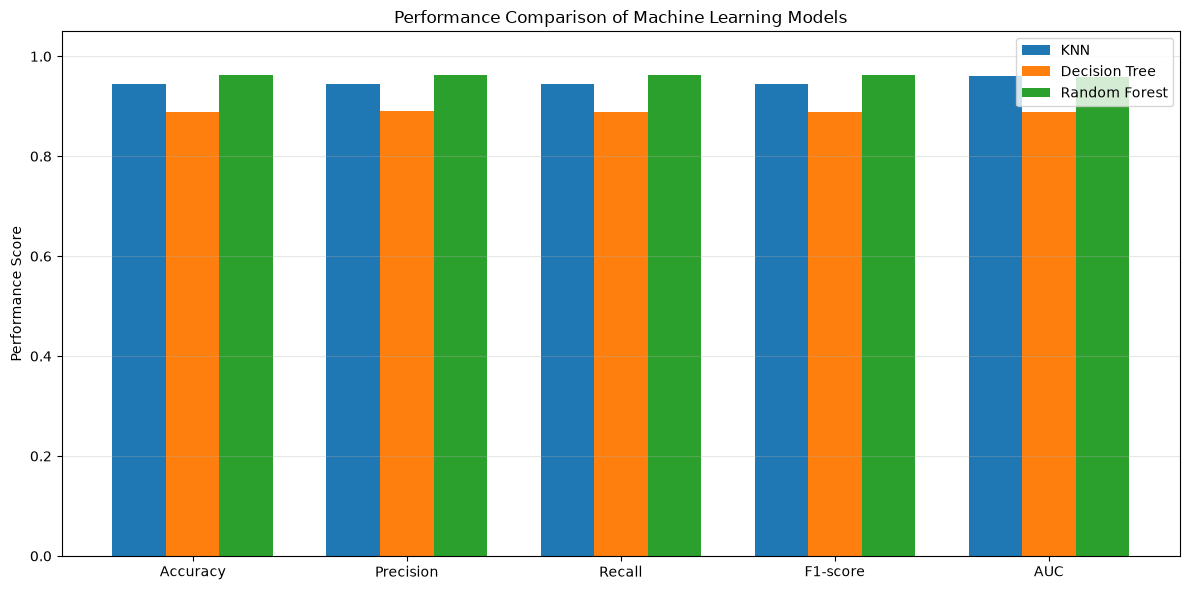

In [140]:
metrics = ["Accuracy","Precision","Recall","F1-score","AUC"]
x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(12,6))
plt.bar(x-width, comparison.loc[0,metrics], width, label="KNN")
plt.bar(x, comparison.loc[1,metrics], width, label="Decision Tree")
plt.bar(x+width, comparison.loc[2,metrics], width, label="Random Forest")
plt.xticks(x, metrics)
plt.ylim(0,1.05)
plt.ylabel("Performance Score")
plt.title("Performance Comparison of Machine Learning Models")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Save trained models for deployment
import joblib

joblib.dump(rf_model, "AI_models+scaled_dataset/RandomForest_Model.pkl")
joblib.dump(dt_model, "AI_models+scaled_dataset/DecisionTree_Model.pkl")
joblib.dump(knn_model, "AI_models+scaled_dataset/KNN_Model.pkl")
joblib.dump(scaler, "AI_models+scaled_dataset/Scaler.pkl")

selected_genes.to_frame(name="Gene").to_csv("datasets/Selected_500_Genes.csv", index=False)
print("Models and gene list saved successfully.")

Models and gene list saved successfully.


In [ ]:
# Load trained model and gene list

rf_model = joblib.load("AI_models+scaled_dataset/RandomForest_Model.pkl")
selected_genes = pd.read_csv("datasets/Selected_500_Genes.csv")["Gene"].tolist()

print(f"Number of Required Genes : {len(selected_genes)}")
print("\nFirst 10 Selected Genes\n")
print(selected_genes[:10])

Number of Required Genes : 500

First 10 Selected Genes

['ALDH6A1', 'CTSB', 'MT1E', 'BGN', 'AKR7A3', 'SIDT2', 'ADTRP', 'UBL3', 'FAM189A2', 'ADGRG2']


In [ ]:
# Load the new patient

patient = pd.read_excel("original_datasets/Patient_1.xlsx")
display(patient.head())

,Hugo_Symbol,Patient_001
0,A1CF,7.387951
1,A2M,11.290425
2,A4GALT,7.034710
3,A4GNT,6.793177
4,AAAS,8.495762


In [144]:
#prepare the new patient

patient = patient.set_index(patient.columns[0]).T
uploaded_genes = patient.shape[1]

print("Patient Matrix Shape:", patient.shape)
print("Patient Value Range :", patient.values.min(), "to", patient.values.max())

Patient Matrix Shape: (1, 11903)
Patient Value Range : 3.81714721377975 to 14.21419663991


No log2 transform here either — 'Patient_1.xlsx' is on the same log-like scale as the training data (values ~3.8–14.2), so we feed it directly into the model, keeping it consistent with the training data's preprocessing state.
                                                                                                         

In [146]:
# Verify gene availability

missing_genes = list(set(selected_genes) - set(patient.columns))

print(f"Required Genes : {len(selected_genes)}")
print(f"Missing Genes  : {len(missing_genes)}")

if len(missing_genes) > 0:
    print("Missing Gene List:", missing_genes)
    raise ValueError("Prediction cannot continue because required genes are missing.")

patient = patient[selected_genes]
matched_genes = patient.shape[1]
print("Final Matrix Shape:", patient.shape)

Required Genes : 500
Missing Genes  : 0
Final Matrix Shape: (1, 500)


In [ ]:
# RF prediction

prediction = rf_model.predict(patient)
probability = rf_model.predict_proba(patient)

class_labels = {0: "Normal", 1: "Gastric Cancer"}
predicted_class = class_labels[prediction[0]]
confidence = np.max(probability) * 100

prob_normal = probability[0][0] * 100
prob_gc = probability[0][1] * 100

In [148]:
# Prediction Report

print("="*70)
print("Tumor Classification Report")
print("="*70)
print(f"Patient ID              : {patient.index[0]}")
print(f"Uploaded Genes          : {uploaded_genes}")
print(f"Genes Required by Model : {len(selected_genes)}")
print(f"Genes Matched           : {matched_genes}")
print(f"Missing Genes           : {len(missing_genes)}")
print(f"Preprocessing Applied   : None (data already log-scaled)")
print(f"Model Used              : Random Forest")
print(f"Prediction              : {predicted_class}")
print(f"Confidence Score        : {confidence:.2f}%")

print("\nClass Probabilities")
print("-"*70)
print(f"Normal                 : {prob_normal:.2f}%")
print(f"Gastric Cancer         : {prob_gc:.2f}%")

if confidence >= 70:
    print("\nInterpretation         : High-confidence prediction")
else:
    print("\nInterpretation         : Low-confidence prediction. Further clinical evaluation is recommended.")

print("="*70)
print("Inference Completed Successfully")
print("="*70)

Tumor Classification Report
Patient ID              : Patient_001
Uploaded Genes          : 11903
Genes Required by Model : 500
Genes Matched           : 500
Missing Genes           : 0
Preprocessing Applied   : None (data already log-scaled)
Model Used              : Random Forest
Prediction              : Gastric Cancer
Confidence Score        : 95.50%

Class Probabilities
----------------------------------------------------------------------
Normal                 : 4.50%
Gastric Cancer         : 95.50%

Interpretation         : High-confidence prediction
Inference Completed Successfully


In [ ]:
# Load Decision Tree
dt_model  = joblib.load("AI_models+scaled_dataset/DecisionTree_Model.pkl")

In [150]:
# Decision Tree Prediction
# DT (like RF) was trained on the raw selected-gene values, no scaling needed
dt_prediction  = dt_model.predict(patient)
dt_probability = dt_model.predict_proba(patient)

dt_predicted_class = class_labels[dt_prediction[0]]
dt_confidence  = np.max(dt_probability) * 100
dt_prob_normal = dt_probability[0][0] * 100
dt_prob_gc     = dt_probability[0][1] * 100

print("="*70)
print("Tumor Classification Report - Decision Tree")
print("="*70)
print(f"Patient ID              : {patient.index[0]}")
print(f"Uploaded Genes          : {uploaded_genes}")
print(f"Genes Required by Model : {len(selected_genes)}")
print(f"Genes Matched           : {matched_genes}")
print(f"Missing Genes           : {len(missing_genes)}")
print(f"Preprocessing Applied   : None (data already log-scaled)")
print(f"Model Used              : Decision Tree")
print(f"Prediction              : {dt_predicted_class}")
print(f"Confidence Score        : {dt_confidence:.2f}%")
print("\nClass Probabilities")
print("-"*70)
print(f"Normal                  : {dt_prob_normal:.2f}%")
print(f"Gastric Cancer          : {dt_prob_gc:.2f}%")

if dt_confidence >= 70:
    print("\nInterpretation          : High-confidence prediction")
else:
    print("\nInterpretation          : Low-confidence prediction. Further clinical evaluation is recommended.")
print("="*70)

Tumor Classification Report - Decision Tree
Patient ID              : Patient_001
Uploaded Genes          : 11903
Genes Required by Model : 500
Genes Matched           : 500
Missing Genes           : 0
Preprocessing Applied   : None (data already log-scaled)
Model Used              : Decision Tree
Prediction              : Gastric Cancer
Confidence Score        : 100.00%

Class Probabilities
----------------------------------------------------------------------
Normal                  : 0.00%
Gastric Cancer          : 100.00%

Interpretation          : High-confidence prediction


In [ ]:
# Load KNN models (+ the scaler used for KNN)

knn_model = joblib.load("AI_models+scaled_dataset/KNN_Model.pkl")
scaler    = joblib.load("AI_models+scaled_dataset/Scaler.pkl")

In [152]:
# KNN Prediction
# KNN WAS trained on standardized features -> must scale the patient
# with the SAME scaler fitted on X_train_selected (not a new one)

patient_scaled = scaler.transform(patient)
patient_scaled_df = pd.DataFrame(
    patient_scaled,
    index=patient.index,
    columns=patient.columns
)

knn_prediction  = knn_model.predict(patient_scaled_df)
knn_probability = knn_model.predict_proba(patient_scaled_df)

knn_predicted_class = class_labels[knn_prediction[0]]
knn_confidence  = np.max(knn_probability) * 100
knn_prob_normal = knn_probability[0][0] * 100
knn_prob_gc     = knn_probability[0][1] * 100

print("="*70)
print("Tumor Classification Report - K-Nearest Neighbors")
print("="*70)
print(f"Patient ID              : {patient.index[0]}")
print(f"Uploaded Genes          : {uploaded_genes}")
print(f"Genes Required by Model : {len(selected_genes)}")
print(f"Genes Matched           : {matched_genes}")
print(f"Missing Genes           : {len(missing_genes)}")
print(f"Preprocessing Applied   : StandardScaler (fitted on training data)")
print(f"Model Used              : K-Nearest Neighbors")
print(f"Prediction              : {knn_predicted_class}")
print(f"Confidence Score        : {knn_confidence:.2f}%")
print("\nClass Probabilities")
print("-"*70)
print(f"Normal                  : {knn_prob_normal:.2f}%")
print(f"Gastric Cancer          : {knn_prob_gc:.2f}%")

if knn_confidence >= 70:
    print("\nInterpretation          : High-confidence prediction")
else:
    print("\nInterpretation          : Low-confidence prediction. Further clinical evaluation is recommended.")
print("="*70)


Tumor Classification Report - K-Nearest Neighbors
Patient ID              : Patient_001
Uploaded Genes          : 11903
Genes Required by Model : 500
Genes Matched           : 500
Missing Genes           : 0
Preprocessing Applied   : StandardScaler (fitted on training data)
Model Used              : K-Nearest Neighbors
Prediction              : Gastric Cancer
Confidence Score        : 100.00%

Class Probabilities
----------------------------------------------------------------------
Normal                  : 0.00%
Gastric Cancer          : 100.00%

Interpretation          : High-confidence prediction


In [ ]:
# Combined Prediction Summary — All Three Models on Patient_1

patient_summary = pd.DataFrame({
    "Model": ["KNN", "Decision Tree", "Random Forest"],
    "Prediction": [knn_predicted_class, dt_predicted_class, predicted_class],
    "Confidence (%)": [
        round(knn_confidence, 2),
        round(dt_confidence, 2),
        round(confidence, 2)
    ]
})

print("="*70)
print("Final Comparison Across All Models")
print("="*70)
display(patient_summary)

patient_summary.to_excel("datasets/Patient_1_All_Models_Prediction.xlsx", index=False)


Final Comparison Across All Models


,Model,Prediction,Confidence (%)
0,KNN,Gastric Cancer,100.0
1,Decision Tree,Gastric Cancer,100.0
2,Random Forest,Gastric Cancer,95.5
